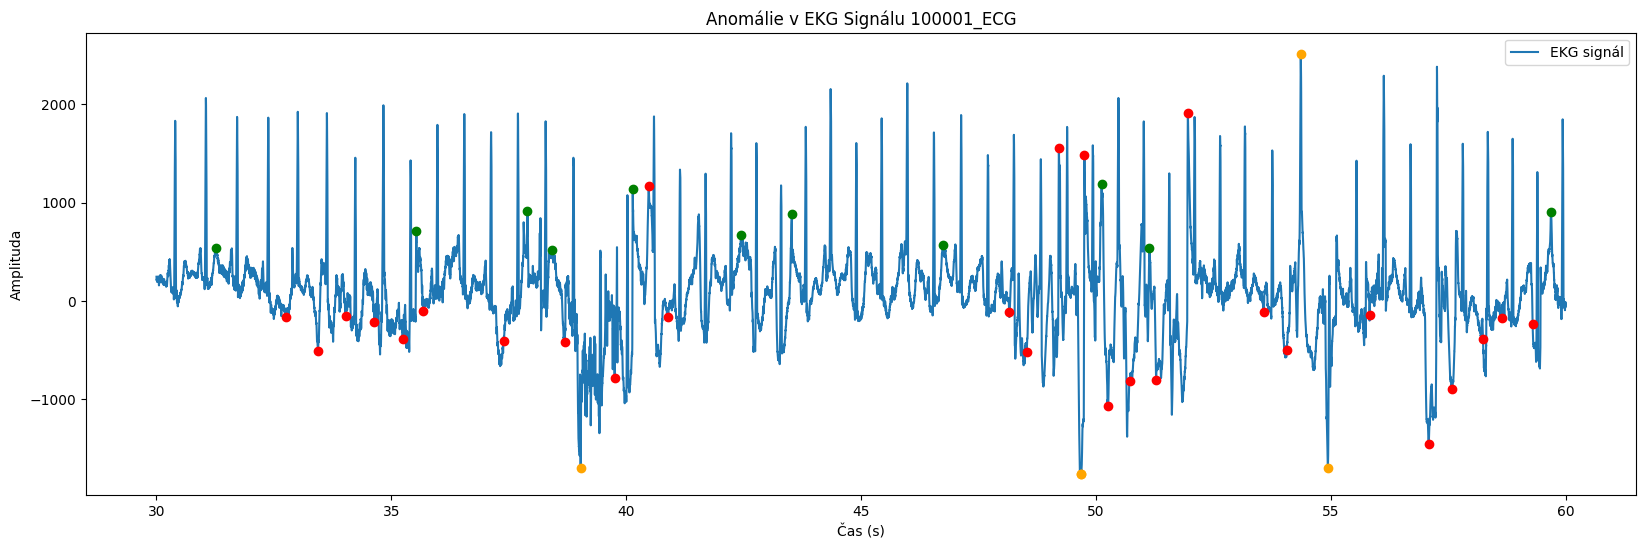

100001_ECG : 
 Vysoké amplitudy R vrcholů:  1 
 Nízké amplitudy:  4 
 P amplitudy nízké:  23 
 P amplitudy vysoké:  4 
 P duration nízký:  0 
 P duration vysoký:  0 
 T amplitudy nízké:  0 
 T amplitudy vysoké:  11 
 T duration nízké:  0 
 T duration vysoké:  0 
 QRS duration nízké:  0 
 QRS duration vysoké:  0 
 Celkem:  43


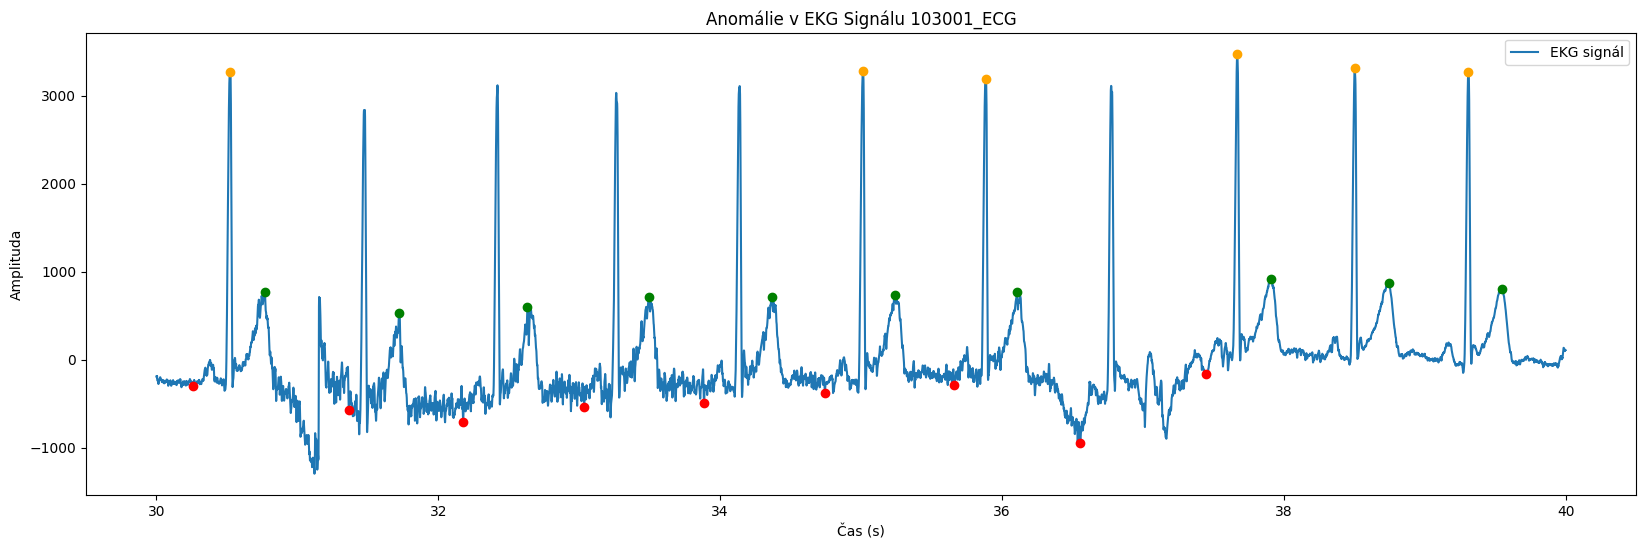

103001_ECG : 
 Vysoké amplitudy R vrcholů:  6 
 Nízké amplitudy:  0 
 P amplitudy nízké:  9 
 P amplitudy vysoké:  0 
 P duration nízký:  0 
 P duration vysoký:  0 
 T amplitudy nízké:  0 
 T amplitudy vysoké:  10 
 T duration nízké:  0 
 T duration vysoké:  0 
 QRS duration nízké:  0 
 QRS duration vysoké:  0 
 Celkem:  25


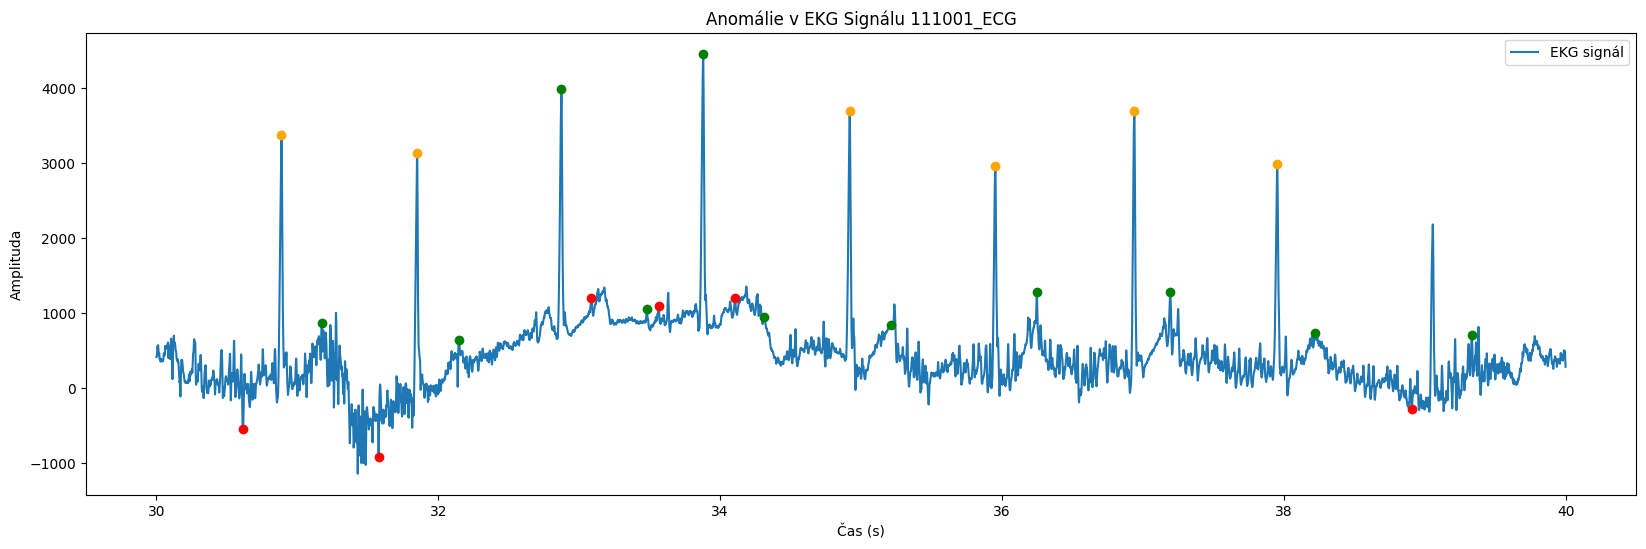

111001_ECG : 
 Vysoké amplitudy R vrcholů:  6 
 Nízké amplitudy:  0 
 P amplitudy nízké:  3 
 P amplitudy vysoké:  3 
 P duration nízký:  0 
 P duration vysoký:  0 
 T amplitudy nízké:  0 
 T amplitudy vysoké:  11 
 T duration nízké:  0 
 T duration vysoké:  0 
 QRS duration nízké:  0 
 QRS duration vysoké:  0 
 Celkem:  23


In [3]:
dolni_mez = 500 
prumer_f = Vypocet_prumerne_frekvence(ecg_signal_30_60, dolni_mez)
min_peaks_height = prumer_f 
catching_time = 0.5 #určím si čas jak často budu zaznamenávat R vrcholy
min_distance = int(vz_f*catching_time) 

#najdu vrcholy
r_peaks_30_60 = r_peaks_finder(ecg_signal_30_60, min_peaks_height, min_distance)
#změřím anomálie
anomalie = detect_anomalies_algoritm(ecg_signal_30_60,r_peaks_30_60,r_peaks_max=2500,r_peaks_min=-1500)
#testování, Funkce, kde si vypíšu si informace o anomáliích.
def print_info(anomalie, signal_name):
    print(signal_name ,': \n', 'Vysoké amplitudy R vrcholů: ',len(anomalie['high_amplitudes']),"\n",'Nízké amplitudy: ',len(anomalie["low_amplitudes"]),"\n",
          'P amplitudy nízké: ',len(anomalie["P_amplow"]),"\n", 'P amplitudy vysoké: ',len(anomalie["P_amphigh"]),"\n", 'P duration nízký: ',len(anomalie["P_durationlow"]),"\n", 'P duration vysoký: ',len(anomalie["P_durationhigh"]),"\n",
          'T amplitudy nízké: ',len(anomalie["T_amplow"]),"\n", 'T amplitudy vysoké: ',len(anomalie["T_amphigh"]),"\n", 'T duration nízké: ',len(anomalie["T_durationlow"]),"\n", 'T duration vysoké: ',len(anomalie["T_durationhigh"]),"\n",
          'QRS duration nízké: ',len(anomalie["QRS_durationlow"]),"\n", 'QRS duration vysoké: ',len(anomalie["QRS_durationhigh"]), '\n Celkem: ', sum(len(value) if isinstance(value,(list)) else 0 for value in anomalie.values()))

plot_anomalies(time_axis_30_60,ecg_signal_30_60,anomalie, signal_name=ecg_mereni.record_name)
print_info(anomalie, signal_name=ecg_mereni.record_name)


#vyzkouším to u jiného ekg měření
def get_signal_measure(file_path): #zase si všechno dám do funkce, abych to mohl vyzkoušet u více měření.
    ecg_mereni = Nacti_soubor(file_path)

    ecg_signal = ecg_mereni.p_signal 
    vz_f = ecg_mereni.__dict__['fs']
    amplitudy = ecg_signal[:, 0]
    #Vezmu si jenom úsek 10 sekund signálu, abych měl větší přehled o tom, jak funguje ta detekce anomálií.
    start_time = 30 
    end_time = 40
    start_index = int(vz_f*start_time) #vezmu si 10 sekund
    end_index = int(vz_f*end_time)
    ecg_signal_30_60 = amplitudy[start_index:end_index] #vezmu amplitudy v daném časovém úseku
    time_axis_30_60 = np.linspace(start_time,end_time,len(ecg_signal_30_60)) #na začátku vidím nějakou anomálii, tak si signál přesunu o 30 sekund dopředu
    dolni_mez = 500 #zvolím si dolní mez od které se bude počítat průměrná ferkvence
    prumer_f = Vypocet_prumerne_frekvence(ecg_signal_30_60, dolni_mez)
    min_peaks_height = prumer_f #dám si průměrnou frekvenci jako minimální výšku vrcholů
    catching_time = 0.5 #pro zpřesnění detekce si určím v ms nějaký detekovací čas
    min_distance = int(vz_f*catching_time) #vynásobím ho se vzorokovací frekvencí
    r_peaks_30_60 = r_peaks_finder(ecg_signal_30_60, min_peaks_height, min_distance) 
    #najdu anomálie v signálu
    anomalie = detect_anomalies_algoritm(ecg_signal_30_60,r_peaks_30_60,r_peaks_max=prumer_f*2.5,r_peaks_min=-2000)
    plot_anomalies(time_axis_30_60,ecg_signal_30_60,anomalie,signal_name=ecg_mereni.record_name)
    #podtím si udělám výpis anomálií
    print_info(anomalie, signal_name=ecg_mereni.record_name)

get_signal_measure(r"C:\Users\ondra\OneDrive\Plocha\brno-university-of-technology-ecg-quality-database-but-qdb-1.0.0\103001\103001_ECG")

#změřím další signál
get_signal_measure(r"C:\Users\ondra\OneDrive\Plocha\brno-university-of-technology-ecg-quality-database-but-qdb-1.0.0\111001\111001_ECG")

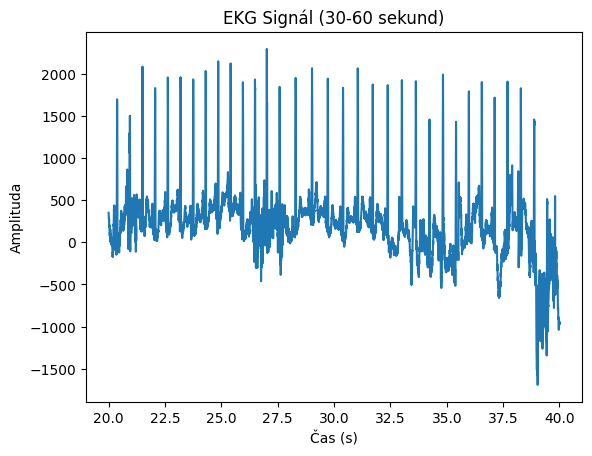

In [30]:
import numpy as np
import wfdb
import matplotlib.pyplot as plt

def nacti_soubor(cesta_k_souboru):
    """Načtení EKG signálu ze souboru MIT-BIH pomocí WFDB."""
    zaznam = wfdb.rdrecord(cesta_k_souboru)
    return zaznam

# Cesta k souboru
ecg_mereni = nacti_soubor(r"C:\Users\ondra\OneDrive\Plocha\brno-university-of-technology-ecg-quality-database-but-qdb-1.0.0\100001\100001_ECG")

ecg_signal = ecg_mereni.p_signal[:, 0]
vz_f = ecg_mereni.fs
start_time, end_time = 20, 40
start_idx, end_idx = int(vz_f * start_time), int(vz_f * end_time)
selected_ecg = ecg_signal[start_idx:end_idx]
time_axis = np.linspace(start_time, end_time, len(selected_ecg))

def detect_r_peaks(signal, threshold, min_gap, debug=False):
    peaks = []
    for idx in range(2, len(signal) - 2):
        if signal[idx] > threshold:
            if signal[idx] > max(signal[idx - 1], signal[idx + 1]) or signal[idx] > max(signal[idx - 2], signal[idx + 2]):
                if not peaks or (idx - peaks[-1] >= min_gap):
                    peaks.append(idx)
                elif debug:
                    print(f"Zanedbaný vrchol (blízký soused): Index {idx}, Amplituda {signal[idx]}")
            elif debug:
                print(f"Zanedbaný vrchol (není lokální maximum): Index {idx}, Amplituda {signal[idx]}")
    return peaks

# Vykreslení vybraného segmentu
plt.plot(time_axis, selected_ecg)
plt.title("EKG Signál (30-60 sekund)")
plt.xlabel("Čas (s)")
plt.ylabel("Amplituda")
plt.show()


In [32]:
def prumerna_frekvence(signaly, prah):
    vybrane_hodnoty = [hodnota for hodnota in signaly if hodnota > prah]  # Filtrace hodnot nad dolní mez
    return sum(vybrane_hodnoty) / len(vybrane_hodnoty) if vybrane_hodnoty else 0

def identifikace_anomalie(signal, r_vrcholy, max_r, min_r):
    abnormality = {
        'vysoke_amplitudy': [], 'nizke_amplitudy': [], "P_nizka_amp": [], "P_vysoka_amp": [],
        "P_kratka_delka": [], "P_dlaha_delka": [], "T_nizka_amp": [], "T_vysoka_amp": [],
        "T_kratka_delka": [], "T_dlaha_delka": [], "QRS_kratka_delka": [], "QRS_dlaha_delka": []
    }
    
    # Hledání nízkých hodnot v signálu
    indexy_min = np.where(signal < min_r)[0]  
    for index in indexy_min:
        if 0 <= index - 50 and index + 50 < len(signal):
            if signal[index] < np.min(signal[index+1:index+50]) and signal[index] < np.min(signal[index-50:index]):
                abnormality["nizke_amplitudy"].append((index, signal[index]))  

    # Identifikace vln na základě R-vrcholů
    for r in r_vrcholy:
        # P vlna (časové rozmezí -300 až -100)
        p_zacatek = max(0, r - 300)
        p_konec = r - 100
        p_usek = signal[p_zacatek:p_konec]
        
        if np.max(p_usek) > 1000:
            abnormality["P_vysoka_amp"].append((p_zacatek + np.argmax(p_usek), np.max(p_usek)))
        elif np.min(p_usek) < -100:
            abnormality["P_nizka_amp"].append((p_zacatek + np.argmin(p_usek), np.min(p_usek)))

        # QRS komplex (-100 až +100)
        qrs_zacatek = max(0, r - 100)
        qrs_konec = min(len(signal), r + 100)
        qrs_usek = signal[qrs_zacatek:qrs_konec]

        if np.max(qrs_usek) > max_r:
            abnormality["vysoke_amplitudy"].append((qrs_zacatek + np.argmax(qrs_usek), np.max(qrs_usek)))

        # T vlna (100 až 300)
        t_zacatek = r + 100
        t_konec = min(len(signal), r + 300)
        t_usek = signal[t_zacatek:t_konec]

        if len(t_usek) > 0:
            if np.max(t_usek) > 500:
                abnormality["T_vysoka_amp"].append((t_zacatek + np.argmax(t_usek), np.max(t_usek)))

    return abnormality

    

In [33]:
def zobraz_anomalie(casova_osa, ekg_signal, abnormality, nazev_signalu):
    plt.figure(figsize=(20, 6))  # Nastavení velikosti grafu
    plt.plot(casova_osa, ekg_signal, label="EKG signál")  # Vykreslení signálu
    
    # Definování barev pro jednotlivé typy abnormalit
    barvy = {
        "P_amplow": "red", "P_amphigh": "red", 
        "T_amplow": "green", "T_amphigh": "green", 
        "QRS_amplow": "blue", "QRS_amphigh": "blue",
        "high_amplitudes": "orange", "low_amplitudes": "purple"
    }
    
    # Vykreslení abnormalit do grafu
    for typ_vlny, hodnoty in abnormality.items():
        if "amp" in typ_vlny or typ_vlny in ["high_amplitudes", "low_amplitudes"]:
            barva = barvy.get(typ_vlny, "black")  # Výchozí barva je černá
            for index, _ in hodnoty:
                plt.plot(casova_osa[index], ekg_signal[index], marker='o', linestyle='None', color=barva)
    
    plt.legend()
    plt.title(f"Detekované anomálie v EKG signálu: {nazev_signalu}")
    plt.xlabel("Čas (s)")
    plt.ylabel("Amplituda")
    plt.show()
